# Model free predictions

Previously, known MDP.

Now no one tells us the environment. 

Estimate the value function of an unknown MDP (unknown state transitions and rewards)

1. Monte-Carlo Learning (MC): run all the way trajectories & estimate value by sampling returns
2. Temporal-Diﬀerence Learning (TD): more efficient in practice. look one step ahead and then estimate the returns
3. TD(λ): unify both MC and TD

Then (next notebok), model-free control: optimize the value function of an unknown MDP

## Monte-carlo RL

- MC methods learn directly from **episodes** of experience (**ONLY for episodic MDP**)
- MC is model-free: no knowledge of MDP transitions / rewards
- MC learns from complete episodes: no bootstrapping
- MC uses the simplest possible idea: value = mean return
- Caveat: can only apply MC to episodic MDPs
- All episodes must terminate

### Policy evaluation

Goal: learn $v_π$ from episodes of experience under policy π

$$S_1,A_1,R_2,...,S_k ∼π$$

Recall that the return is the total discounted reward:

$$G_t = R_{t+1} + γR_{t+2} +...+ γ^{T−1}R_T$$

Recall that the value function is the expected return:

$$v_π (s) = E_π [G_t |S_t = s]$$

Monte-Carlo policy evaluation uses empirical mean return
instead of expected return

### First-Visit Monte-Carlo Policy Evaluation

- To evaluate state s
- We run it for **multiple episodes**
- The **first** time-step t that state s is visited in an episode, (to handle loop situation where we come back to state)
- Increment counter $N(s) ←N(s) + 1$ (in every episode but once per episode)
- Increment total return $S(s) ←S(s) + G_t$
- Value is estimated by mean return $V (s) = S(s)/N(s)$
- By law of large numbers, $V (s) →v_π (s)$ as $N(s) → \infty$

### Every-Visit Monte-Carlo Policy Evaluation

- To evaluate state s
- Every time-step t that state s is visited in an episode,
- Increment counter $N(s) ←N(s) + 1$
- Increment total return $S(s) ←S(s) + G_t$
- Value is estimated by mean return $V (s) = S(s)/N(s)$
- Again, $V (s) →v_π (s)$ as $N(s) →\infty$

### Incremental mean

A concept used everywhere in RL

The mean $µ_1$,$µ_2$,... of a sequence $x_1$,$x_2$,... can be computed
incrementally,

Instead of keeping track of massive sum of number you've seen, you need to remember 2 things: current average ($\mu_{k-1}$) and how many items you've counted ($k$)

$$
\begin{aligned}
\mu_k &= \frac{1}{k} \sum_{j=1}^{k} x_j \\
&= \frac{1}{k} \left( x_k + \sum_{j=1}^{k-1} x_j \right) \\
&= \frac{1}{k} (x_k + (k-1)\mu_{k-1}) \\
&= \mu_{k-1} + \frac{1}{k}(x_k - \mu_{k-1})
\end{aligned}
$$

Here 
- $\mu_{k-1}$ is the current average or estimation at previous step
- **Error gap:** ($x_k - \mu_{k-1}$), represent the difference between your new data point ($x_k$) and your current average ($\mu_{k-1}$)
- **Learning rate:** fraction $\frac{1}{k}$ determine how much weigbht you give to this new piece of information


### Black jack

- States (200 of them):
    - Current sum (12-21)
    - Dealer’s showing card (ace-10). Ace 1 or 10 ?
    - Do I have a “useable” ace? (yes-no)
- Action stick: Stop receiving cards (and terminate)
- Action twist: Take another card (no replacement)
- Reward for stick:
    - +1 if sum of cards > sum of dealer cards
    - 0 if sum of cards = sum of dealer cards
    - -1 if sum of cards < sum of dealer cards
- Reward for twist:
    - -1 if sum of cards >21 (and terminate)
    - 0 otherwise
- Transitions: automatically twist if sum of cards <12

Policy: stick if sum of cards ≥20, otherwise twist


In [1]:
import numpy as np
import pandas as pd
import random

def get_card():
    card = random.randint(1, 13)
    return min(card, 10)

def get_score(hand):
    """Returns (sum, has_usable_ace)"""
    score = sum(hand)
    usable_ace = False
    if 1 in hand and score + 10 <= 21:
        score += 10
        usable_ace = True
    return score, usable_ace

def play_episode(policy):
    player_hand = [get_card(), get_card()]
    dealer_up_card = get_card()
    
    episode_history = []
    
    # Player's Turn
    while True:
        p_sum, usable_ace = get_score(player_hand)
        
        # Auto-twist if sum < 12
        if p_sum < 12:
            player_hand.append(get_card())
            continue
            
        # Decision Zone (12-21)
        state = (p_sum, dealer_up_card, usable_ace)
        
        # Policy: Stick if >= 20, else Twist
        action = "stick" if p_sum >= 20 else "twist"
        
        if action == "twist":
            episode_history.append(state)
            player_hand.append(get_card())
            if get_score(player_hand)[0] > 21:
                return episode_history, -1 # Bust
        else:
            episode_history.append(state)
            break
            
    # Dealer's Turn (Fixed Strategy: Hits until 17)
    dealer_hand = [dealer_up_card, get_card()]
    while True:
        d_sum, _ = get_score(dealer_hand)
        if d_sum >= 17:
            break
        dealer_hand.append(get_card())
        
    # Determine Final Reward
    p_sum, _ = get_score(player_hand)
    d_sum, _ = get_score(dealer_hand)
    
    if d_sum > 21 or p_sum > d_sum:
        reward = 1
    elif p_sum == d_sum:
        reward = 0
    else:
        reward = -1
        
    return episode_history, reward

# --- Initialization ---
# Dimensions: [Player Sum 12-21, Dealer Card 1-10, Usable Ace 0-1]
V = np.zeros((10, 10, 2))
N = np.zeros((10, 10, 2)) # Counter for incremental mean

# --- Main Loop ---
num_episodes = 500000
for _ in range(num_episodes):
    history, reward = play_episode(None) # Policy is hardcoded inside play_episode
    
    visited_states = set()
    for (p_sum, d_card, ace) in history:
        # Map state to array indices
        idx = (p_sum - 12, d_card - 1, int(ace))
        
        if idx not in visited_states:
            N[idx] += 1
            # Incremental Mean Update: V = V + (1/N) * (G - V)
            V[idx] += (1 / N[idx]) * (reward - V[idx])
            visited_states.add(idx)

# Example Output
print(f"Value of state (Sum=20, Dealer=5, No Usable Ace): {V[20-12, 5-1, 0]:.4f}")
print(f"Value of state (Sum=19, Dealer=5, No Usable Ace): {V[19-12, 5-1, 0]:.4f}")
print(f"Value of state (Sum=13, Dealer=10, No Usable Ace): {V[13-12, 10-1, 0]:.4f}")

# Print all states in a compact table
rows = []
for p_sum in range(12, 22):
    for d_card in range(1, 11):
        for u_ace in [False, True]:
            rows.append(
                {
                    "player_sum": p_sum,
                    "dealer_card": d_card,
                    "usable_ace": u_ace,
                    "value": V[p_sum - 12, d_card - 1, int(u_ace)],
                }
            )

states_df = pd.DataFrame(rows)
states_df

Value of state (Sum=20, Dealer=5, No Usable Ace): 0.6597
Value of state (Sum=19, Dealer=5, No Usable Ace): -0.7205
Value of state (Sum=13, Dealer=10, No Usable Ace): -0.5975


,player_sum,dealer_card,usable_ace,value
0,12,1,False,-0.643249
1,12,1,True,-0.354167
2,12,2,False,-0.544251
3,12,2,True,-0.194595
4,12,3,False,-0.524035
...,...,...,...,...
195,21,8,True,0.926343
196,21,9,False,0.943179
197,21,9,True,0.945470
198,21,10,False,0.890085


**How it Works**
- State Representation: We use a 3D NumPy array to store values. The axes represent the three components of your state:

    - Player Sum (Index 0-9 maps to 12-21)

    - Dealer Card (Index 0-9 maps to 1-10)

    - Usable Ace (Index 0-1 maps to No/Yes)

- The Policy: The code follows your logic: if the player's sum is 18 or 19, they will "twist" (hit), which usually results in a high probability of busting, hence lower values for those states.

- The Reward: The reward is only propagated back once the episode ends, which is the core characteristic of Monte Carlo methods—learning from complete sequences.

**Observations**
With your specific policy (sticking only at 20 or 21), you will likely notice that states where the sum is 12–19 have quite low (negative) values. This is because "twisting" on a 19 is extremely risky!

### Incremental Monte-Carlo Updates

Update $V(s)$ incrementally after episode $S_1, A_1, R_2, \dots, S_T$

For each state $S_t$ with return $G_t$
$$\begin{aligned}
N(S_t) &\leftarrow N(S_t) + 1 \\
V(S_t) &\leftarrow V(S_t) + \frac{1}{N(S_t)} (G_t - V(S_t))
\end{aligned}$$

$N(S_t)$ : counter for how many times you've visited a state. Using $\frac{1}{N(S_t)}$, every experience is equaly weighted to find true average of rewards


**Non-stationary**
In non-stationary problems, it can be useful to track a running mean, i.e. forget old episodes.
$$V(S_t) \leftarrow V(S_t) + \alpha (G_t - V(S_t))$$

In many games, rules or the env may change over time. With standard average (old data from 1000 episodes ago will still influence current value). 

So we replace $\frac{1}{N(S_t)}$ with constant $\alpha$, which is the learning rate. 

As $\alpha$ don't get smaller over time, agent prioritize recent rewards.

## Temporal difference learning


- TD methods learn directly from episodes of experience
- TD is model-free: no knowledge of MDP transitions / rewards
- TD learns from incomplete episodes, by bootstrapping
- TD updates a guess towards a guess

### MC and TD

- **Goal**: learn $v_\pi$ online from experience under policy $\pi$
- **Incremental every-visit Monte-Carlo**
  - Update value $V(S_t)$ toward *actual* return $G_t$
  - $$V(S_t) \leftarrow V(S_t) + \alpha(G_t - V(S_t))$$
  - update is an average: move $V(S_t)$ a little bit toward real outcome
  - Unbiaised (true return), but high variance (full trajectory can vary a lot, return depends on many random actions, transitions and rewards)

- **Simplest temporal-difference learning algorithm: TD(0)**
  - Update value $V(S_t)$ toward *estimated* return $R_{t+1} + \gamma V(S_{t+1})$
  - $$V(S_t) \leftarrow V(S_t) + \alpha(R_{t+1} + \gamma V(S_{t+1}) - V(S_t))$$
  - Don't wait for end of episode -> update after every step
  - $R_{t+1} + \gamma V(S_{t+1})$ is called the **TD target**. 
  Instead of true $G_t$, use a boostrap estimate (one real reward $R_{t+1}$, then substitute $V(S_{t+1})$)
  - lower variance (depends on one random action, transition, reward), but biaised (because $V(S_{t+1}$ is an estimate)
  
  - $\delta_t = R_{t+1} + \gamma V(S_{t+1}) - V(S_t)$ is called the **TD error**.
  TD error is the surprise: how much bettter or worse the outcome was compared to your current estimate. The whole update is just "nudge" $V(S_t)$ by $\alpha * \delta_t $

#### Tradeoff
- MC wait for truth (unbiaised, slow)
- TD bootstrap immediately (biased, fast)


In [2]:
# ...existing code...
import numpy as np
import pandas as pd
import random

# TD(0): V(S_t) <- V(S_t) + alpha * (R_{t+1} + gamma * V(S_{t+1}) - V(S_t))
alpha = 0.01
gamma = 1.0
num_episodes = 500_000

# Same state layout as MC: [player_sum 12-21, dealer_card 1-10, usable_ace 0/1]
V_td0 = np.zeros((10, 10, 2), dtype=float)
td_err_curve = np.zeros(num_episodes, dtype=float)

def state_to_idx(player_sum, dealer_card, usable_ace):
    return (player_sum - 12, dealer_card - 1, int(usable_ace))

for ep in range(num_episodes):
    player_hand = [get_card(), get_card()]
    dealer_up_card = get_card()

    # Auto-twist until decision zone [12..21]
    p_sum, usable_ace = get_score(player_hand)
    while p_sum < 12:
        player_hand.append(get_card())
        p_sum, usable_ace = get_score(player_hand)

    done = False
    td_err_sum = 0.0
    td_steps = 0

    while not done:
        s_idx = state_to_idx(p_sum, dealer_up_card, usable_ace)

        # Policy from markdown: stick if sum >= 20, else twist
        action = "stick" if p_sum >= 20 else "twist"

        if action == "twist":
            player_hand.append(get_card())
            p_next, ace_next = get_score(player_hand)

            if p_next > 21:
                reward = -1.0
                td_target = reward
                done = True
            else:
                while p_next < 12:
                    player_hand.append(get_card())
                    p_next, ace_next = get_score(player_hand)

                if p_next > 21:
                    reward = -1.0
                    td_target = reward
                    done = True
                else:
                    reward = 0.0
                    s_next_idx = state_to_idx(p_next, dealer_up_card, ace_next)
                    td_target = reward + gamma * V_td0[s_next_idx]

        else:  # stick -> terminal after dealer plays
            dealer_hand = [dealer_up_card, get_card()]
            d_sum, _ = get_score(dealer_hand)
            while d_sum < 17:
                dealer_hand.append(get_card())
                d_sum, _ = get_score(dealer_hand)

            p_final, _ = get_score(player_hand)
            if d_sum > 21 or p_final > d_sum:
                reward = 1.0
            elif p_final == d_sum:
                reward = 0.0
            else:
                reward = -1.0

            td_target = reward
            done = True

        td_error = td_target - V_td0[s_idx]
        V_td0[s_idx] += alpha * td_error

        td_err_sum += abs(td_error)
        td_steps += 1

        if not done:
            p_sum, usable_ace = p_next, ace_next

    td_err_curve[ep] = td_err_sum / max(td_steps, 1)

print(f"V(sum=20, dealer=5, no usable ace): {V_td0[20-12, 5-1, 0]:.4f}")
print(f"V(sum=19, dealer=5, no usable ace): {V_td0[19-12, 5-1, 0]:.4f}")
print(f"V(sum=13, dealer=10, no usable ace): {V_td0[13-12, 10-1, 0]:.4f}")

rows = []
for p_sum in range(12, 22):
    for d_card in range(1, 11):
        for u_ace in [False, True]:
            rows.append(
                {
                    "player_sum": p_sum,
                    "dealer_card": d_card,
                    "usable_ace": u_ace,
                    "value_td0": V_td0[p_sum - 12, d_card - 1, int(u_ace)],
                }
            )

td0_states_df = pd.DataFrame(rows)
td0_states_df


V(sum=20, dealer=5, no usable ace): 0.6703
V(sum=19, dealer=5, no usable ace): -0.7085
V(sum=13, dealer=10, no usable ace): -0.6277


,player_sum,dealer_card,usable_ace,value_td0
0,12,1,False,-0.658568
1,12,1,True,-0.355872
2,12,2,False,-0.471277
3,12,2,True,-0.184846
4,12,3,False,-0.623155
...,...,...,...,...
195,21,8,True,0.914778
196,21,9,False,0.926138
197,21,9,True,0.959660
198,21,10,False,0.873667


     player_sum  dealer_card  usable_ace     value  value_mc  value_td0  \
0            12            1       False -0.643249 -0.643249  -0.658568   
1            12            1        True -0.354167 -0.354167  -0.355872   
2            12            2       False -0.544251 -0.544251  -0.471277   
3            12            2        True -0.194595 -0.194595  -0.184846   
4            12            3       False -0.524035 -0.524035  -0.623155   
..          ...          ...         ...       ...       ...        ...   
195          21            8        True  0.926343  0.926343   0.914778   
196          21            9       False  0.943179  0.943179   0.926138   
197          21            9        True  0.945470  0.945470   0.959660   
198          21           10       False  0.890085  0.890085   0.873667   
199          21           10        True  0.884279  0.884279   0.891102   

     difference  
0      0.015319  
1      0.001705  
2     -0.072974  
3     -0.009749  
4      0.

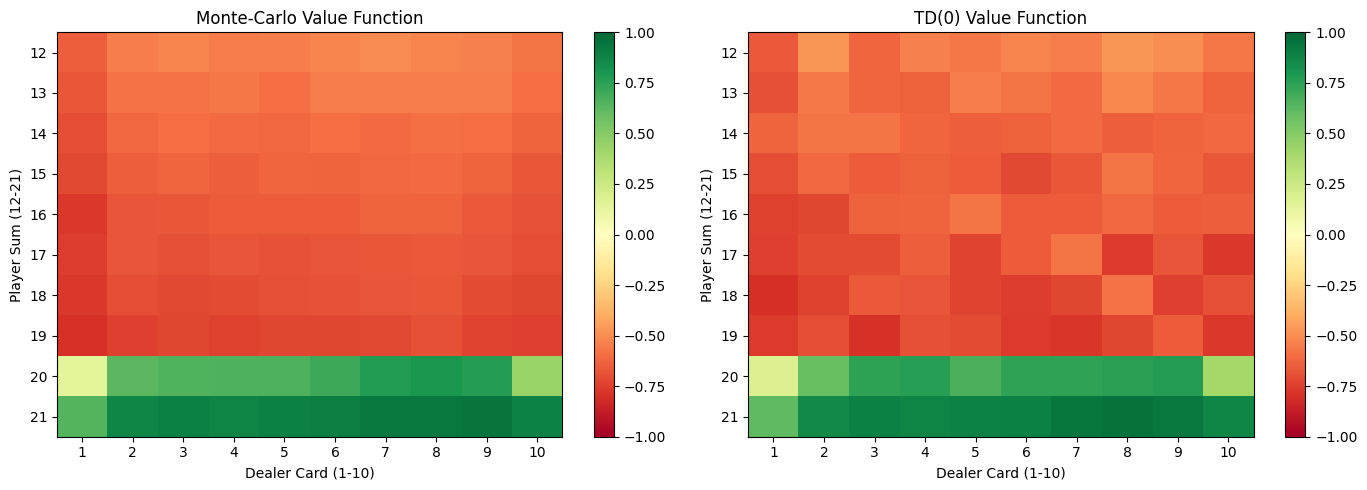

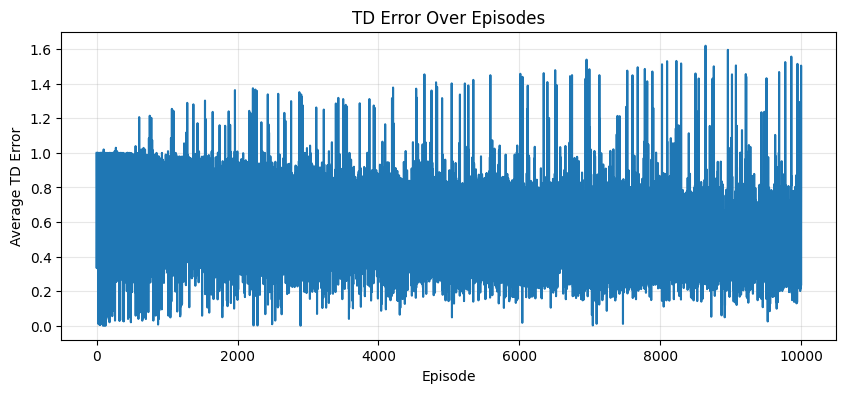

In [3]:
import matplotlib.pyplot as plt

# Create comparison dataframe
comparison_df = states_df.copy()
comparison_df['value_mc'] = comparison_df.apply(
    lambda row: V[row['player_sum'] - 12, row['dealer_card'] - 1, int(row['usable_ace'])],
    axis=1
)
comparison_df['value_td0'] = comparison_df.apply(
    lambda row: V_td0[row['player_sum'] - 12, row['dealer_card'] - 1, int(row['usable_ace'])],
    axis=1
)
comparison_df['difference'] = comparison_df['value_mc'] - comparison_df['value_td0']

print(comparison_df)

# Visualization: Compare MC vs TD values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MC values
mc_values = V[:, :, 0]  # No usable ace
im1 = axes[0].imshow(mc_values, cmap='RdYlGn', aspect='auto', vmin=-1, vmax=1)
axes[0].set_title('Monte-Carlo Value Function')
axes[0].set_xlabel('Dealer Card (1-10)')
axes[0].set_ylabel('Player Sum (12-21)')
axes[0].set_xticks(range(10))
axes[0].set_xticklabels(range(1, 11))
axes[0].set_yticks(range(10))
axes[0].set_yticklabels(range(12, 22))
plt.colorbar(im1, ax=axes[0])

# TD values
td_values = V_td0[:, :, 0]  # No usable ace
im2 = axes[1].imshow(td_values, cmap='RdYlGn', aspect='auto', vmin=-1, vmax=1)
axes[1].set_title('TD(0) Value Function')
axes[1].set_xlabel('Dealer Card (1-10)')
axes[1].set_ylabel('Player Sum (12-21)')
axes[1].set_xticks(range(10))
axes[1].set_xticklabels(range(1, 11))
axes[1].set_yticks(range(10))
axes[1].set_yticklabels(range(12, 22))
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

# Plot TD error convergence
plt.figure(figsize=(10, 4))
plt.plot(td_err_curve[:10000])
plt.title('TD Error Over Episodes')
plt.xlabel('Episode')
plt.ylabel('Average TD Error')
plt.grid(True, alpha=0.3)
plt.show()

### Advantages and Disadvantages of MC vs. TD

#### TD

- TD can learn before knowing the final outcome

    - TD can learn online after every step
    - MC must wait until end of episode before return is known

- TD can learn without the final outcome

    - TD can learn from incomplete sequences
    - MC can only learn from complete sequences
    - TD works in continuing (non-terminating) environments
    - MC only works for episodic (terminating) environments
- more efficient than MC
- more sensitive to initial value

#### MC 

- Good convergence 
- Not very sensitive to initial value
- simple to understand and use


### Batch MC and TD

- MC and TD converge: $V(s) \rightarrow v_\pi(s)$ as experience $\rightarrow \infty$
- But what about batch solution for finite experience?

$$s_1^1, a_1^1, r_2^1, \ldots, s_{T_1}^1$$
$$\vdots$$
$$s_1^K, a_1^K, r_2^K, \ldots, s_{T_K}^K$$

- e.g. Repeatedly sample episode $k \in [1, K]$
- Apply MC or TD(0) to episode $k$

Both MC and TD are guaranteed to converge to the true $v_\pi(s)$ given
infinite experience — that's the theory. 
But in practice you have a fixed finite dataset of K episodes.

**Batch setting**: instead of collecting new data forever, you have K recorded episodes and you repeatedly loop over them, applying MC or TD updates each pass. This is called batch learning.

Given the same finite data, do MC and TD converge to the same answer? The answer is no 